In [1]:
import torch
import datajoint as dj
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.prior_tables import FlowPriorConfig, AdaptPriorConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    FlowPriorResult,
    FPSamples,
    FPSamplesConfig,
    LikelihoodResult,
    MLPCondSamples,
    MLPCondSamplesConfig,
    SBVGPResult,
    SIResult,
    AdaptPriorResult,
)
from experiments.dj.evaluation_tables import SIEval, SBVGPEval
from experiments.dj.trainer_tables import (
    FPTrainerConfig,
    LLTrainerConfig,
    SBVGPTrainerConfig,
    SITrainerConfig,
    AdaptPriorTrainer,
)
from experiments.dj.schema import schema
from experiments.dj.dj_helpers import drop_schema_dot_jobs
from experiments.dj.dj_helpers import fetch_best_model_results
import experiments.orientation_discrimination.haefner_model.configs as cfg
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.utils.model_utils import build_haefner_model
from task_transfer.evaluation.evaluate_generative_model import compute_logl, compute_haefner_logl_i_cond_x, visualize_conditional_features
from pathlib import Path

[2024-07-04 10:27:00,884][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-04 10:27:00,980][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
LikelihoodResult()

ll_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
44a8edea52d1adc36a06935005d2faa7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,125.74639129638672,1.1399195194244385,124.45130157470703,2.2416083812713623,124.45130157470703,2.2416083812713623,=BLOB=,=BLOB=,=BLOB=
a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,125.39987182617188,1.1455481052398682,124.65189361572266,2.2731430530548096,124.65189361572266,2.2731430530548096,=BLOB=,=BLOB=,=BLOB=


In [3]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

In [4]:
likelihood_config_proj_col = "ll_id"

best_val_likelihood_results = fetch_best_model_results(
    result_table=LikelihoodResult,
    config_table=LikelihoodConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)

In [5]:
likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

In [6]:
haefner_model = build_haefner_model(
    p_c=cfg.orginal_haefner_2afc_task1['p_c'],
    c1_psi=cfg.orginal_haefner_2afc_task1['c1_psi'],
    c2_psi=cfg.orginal_haefner_2afc_task1['c2_psi'],
    kappa=cfg.orginal_haefner_2afc_task1['kappa'],
    g_phi=cfg.orginal_haefner_2afc_task1['g_phi'],
    delta=cfg.orginal_haefner_2afc_task1['delta'],
    lam=cfg.orginal_haefner_2afc_task1['lam'],
    x_phi=cfg.orginal_haefner_2afc_task1['x_phi'],
    obs_sigma=cfg.orginal_haefner_2afc_task1['obs_sigma'],
    obs_h=cfg.orginal_haefner_2afc_task1['obs_h'],
    obs_w=cfg.orginal_haefner_2afc_task1['obs_w'],
)

In [7]:
dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

In [8]:
logl_ix_true_train, _ = compute_haefner_logl_i_cond_x(
    haefner_model=haefner_model,
    data_loader=train_loader,
    reduction="none",
    uncertainty="sem",
    normalize="per_dim",
    unit="nats",
)
logl_ix_true_val, _ = compute_haefner_logl_i_cond_x(
    haefner_model=haefner_model,
    data_loader=val_loader,
    reduction="none",
    uncertainty="sem",
    normalize="per_dim",
    unit="nats",
)
logl_ix_true_test, _ = compute_haefner_logl_i_cond_x(
    haefner_model=haefner_model,
    data_loader=test_loader,
    reduction="none",
    uncertainty="sem",
    normalize="per_dim",
    unit="nats",
)

In [9]:
data_dim = 1
cond_dim = 0
logl_ix_model_train, _ = compute_logl(
    model=likelihood_model,
    data_loader=train_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="nats",
)
logl_ix_model_val, _ = compute_logl(
    model=likelihood_model,
    data_loader=val_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="nats",
)
logl_ix_model_test, _ = compute_logl(
    model=likelihood_model,
    data_loader=test_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    reduction="none",
    uncertainty="none",
    normalize="per_dim",
    unit="nats",
)

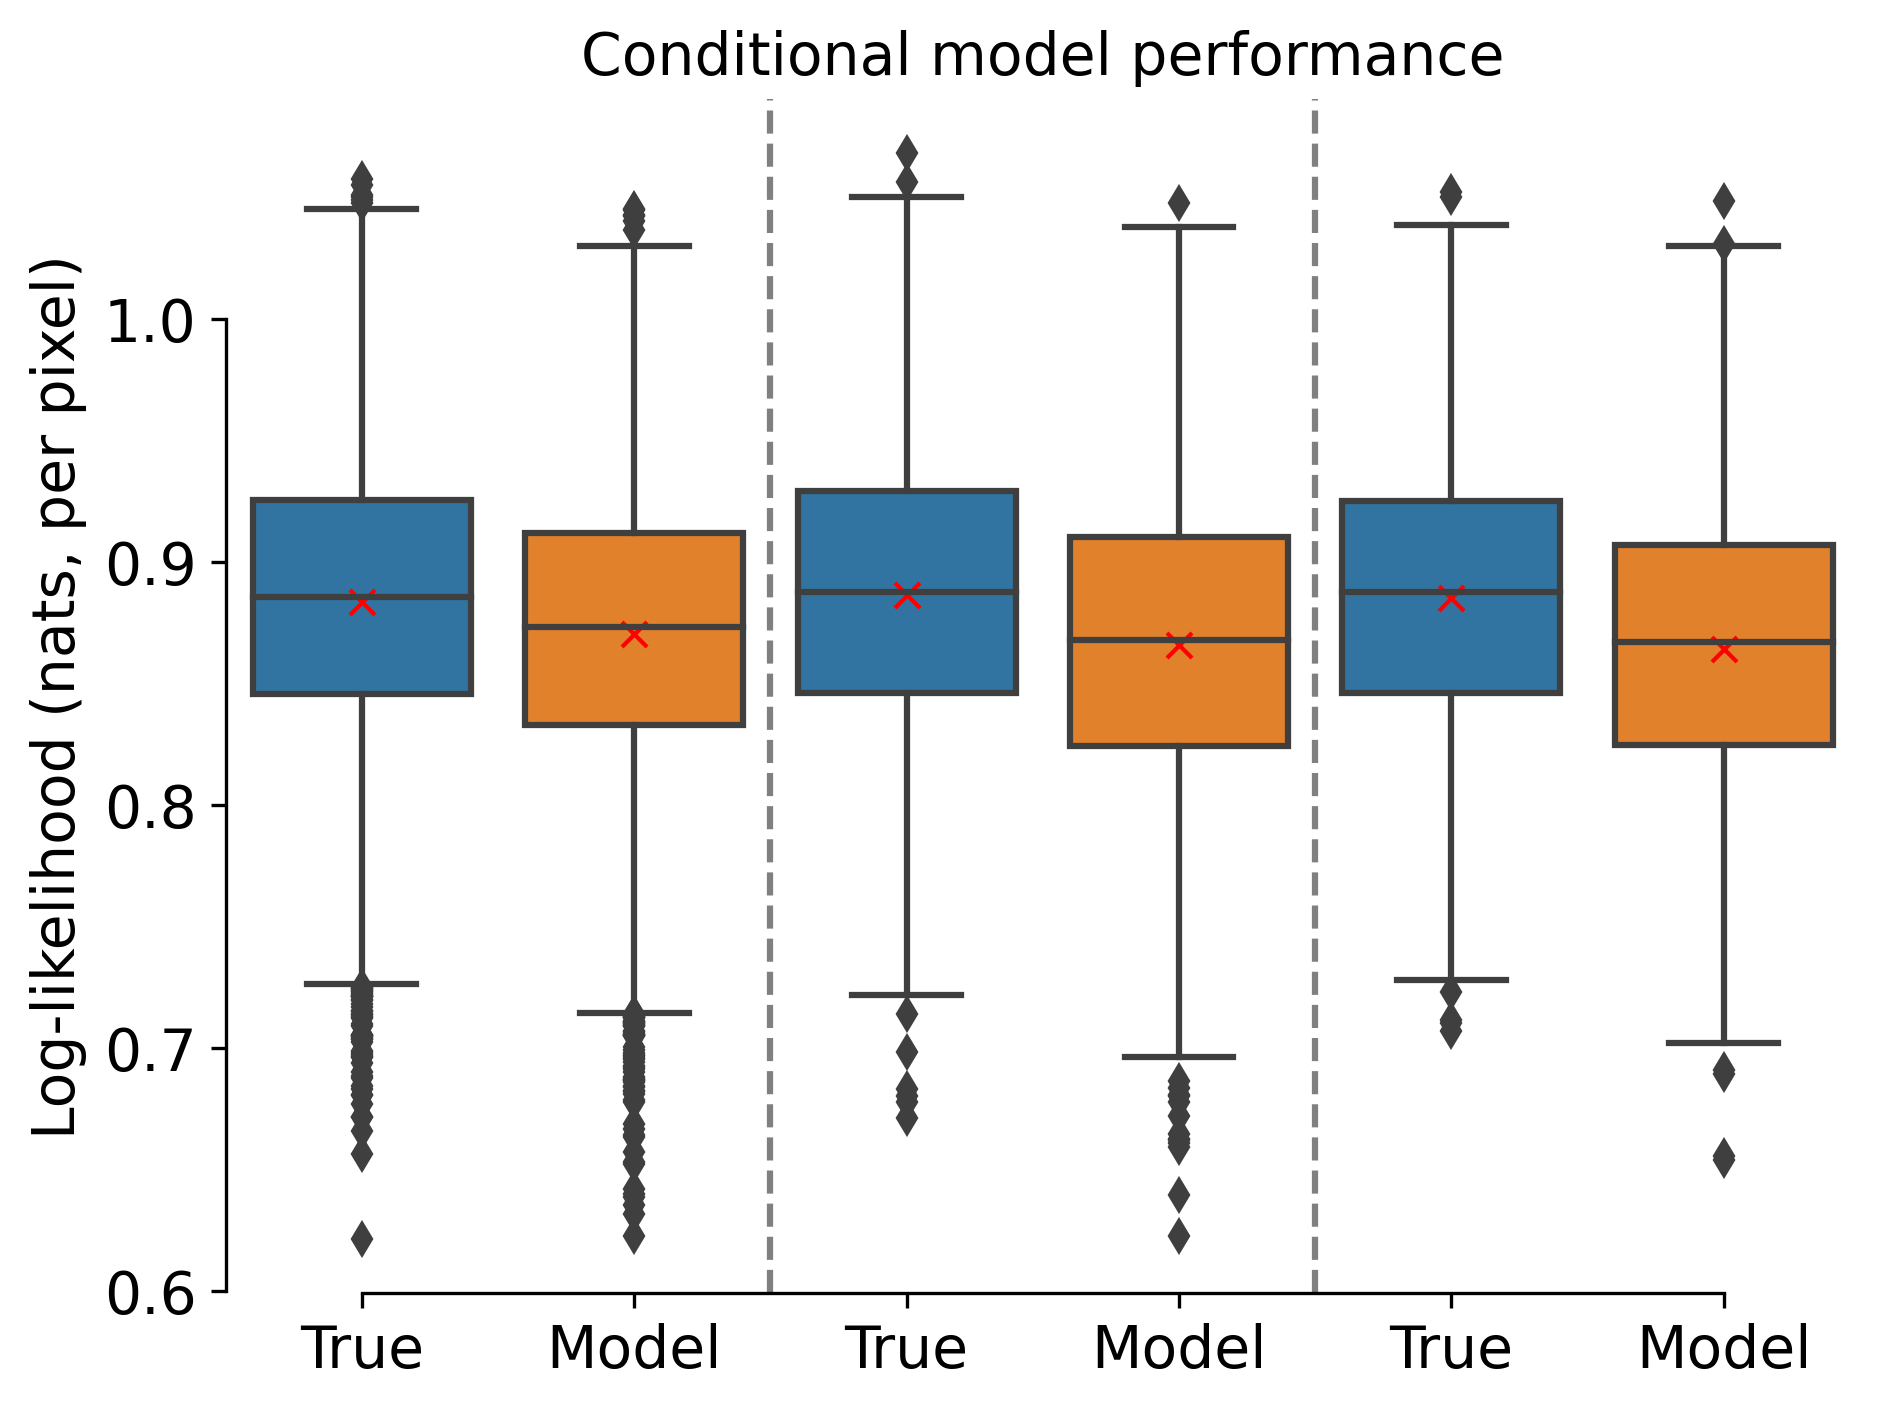

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
data = [
    logl_ix_true_train,
    logl_ix_model_train,
    logl_ix_true_val,
    logl_ix_model_val,
    logl_ix_true_test,
    logl_ix_model_test,
]
labels = [
    "True",
    "Model",
    "True",
    "Model",
    "True",
    "Model",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=2)
ax = sns.boxplot(data=data, ax=ax, palette=palette)
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels)
ax.set_title("Conditional model performance", fontsize=14)
ax.set_ylabel("Log-likelihood (nats, per pixel)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 2 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [11]:
visualize_conditional_features(
    conditional=likelihood_model,
    data_loader=test_loader,
    epoch="post_learning",
    unit_perturbation=1,
    device="cpu",
    dims_to_plot=range(45),
    fig_dpi=300,
    fig_save_dir=Path("/src/project/figures/learning/"),
)

In [13]:
haefner_model.x_pfs.shape

torch.Size([45, 12, 12])

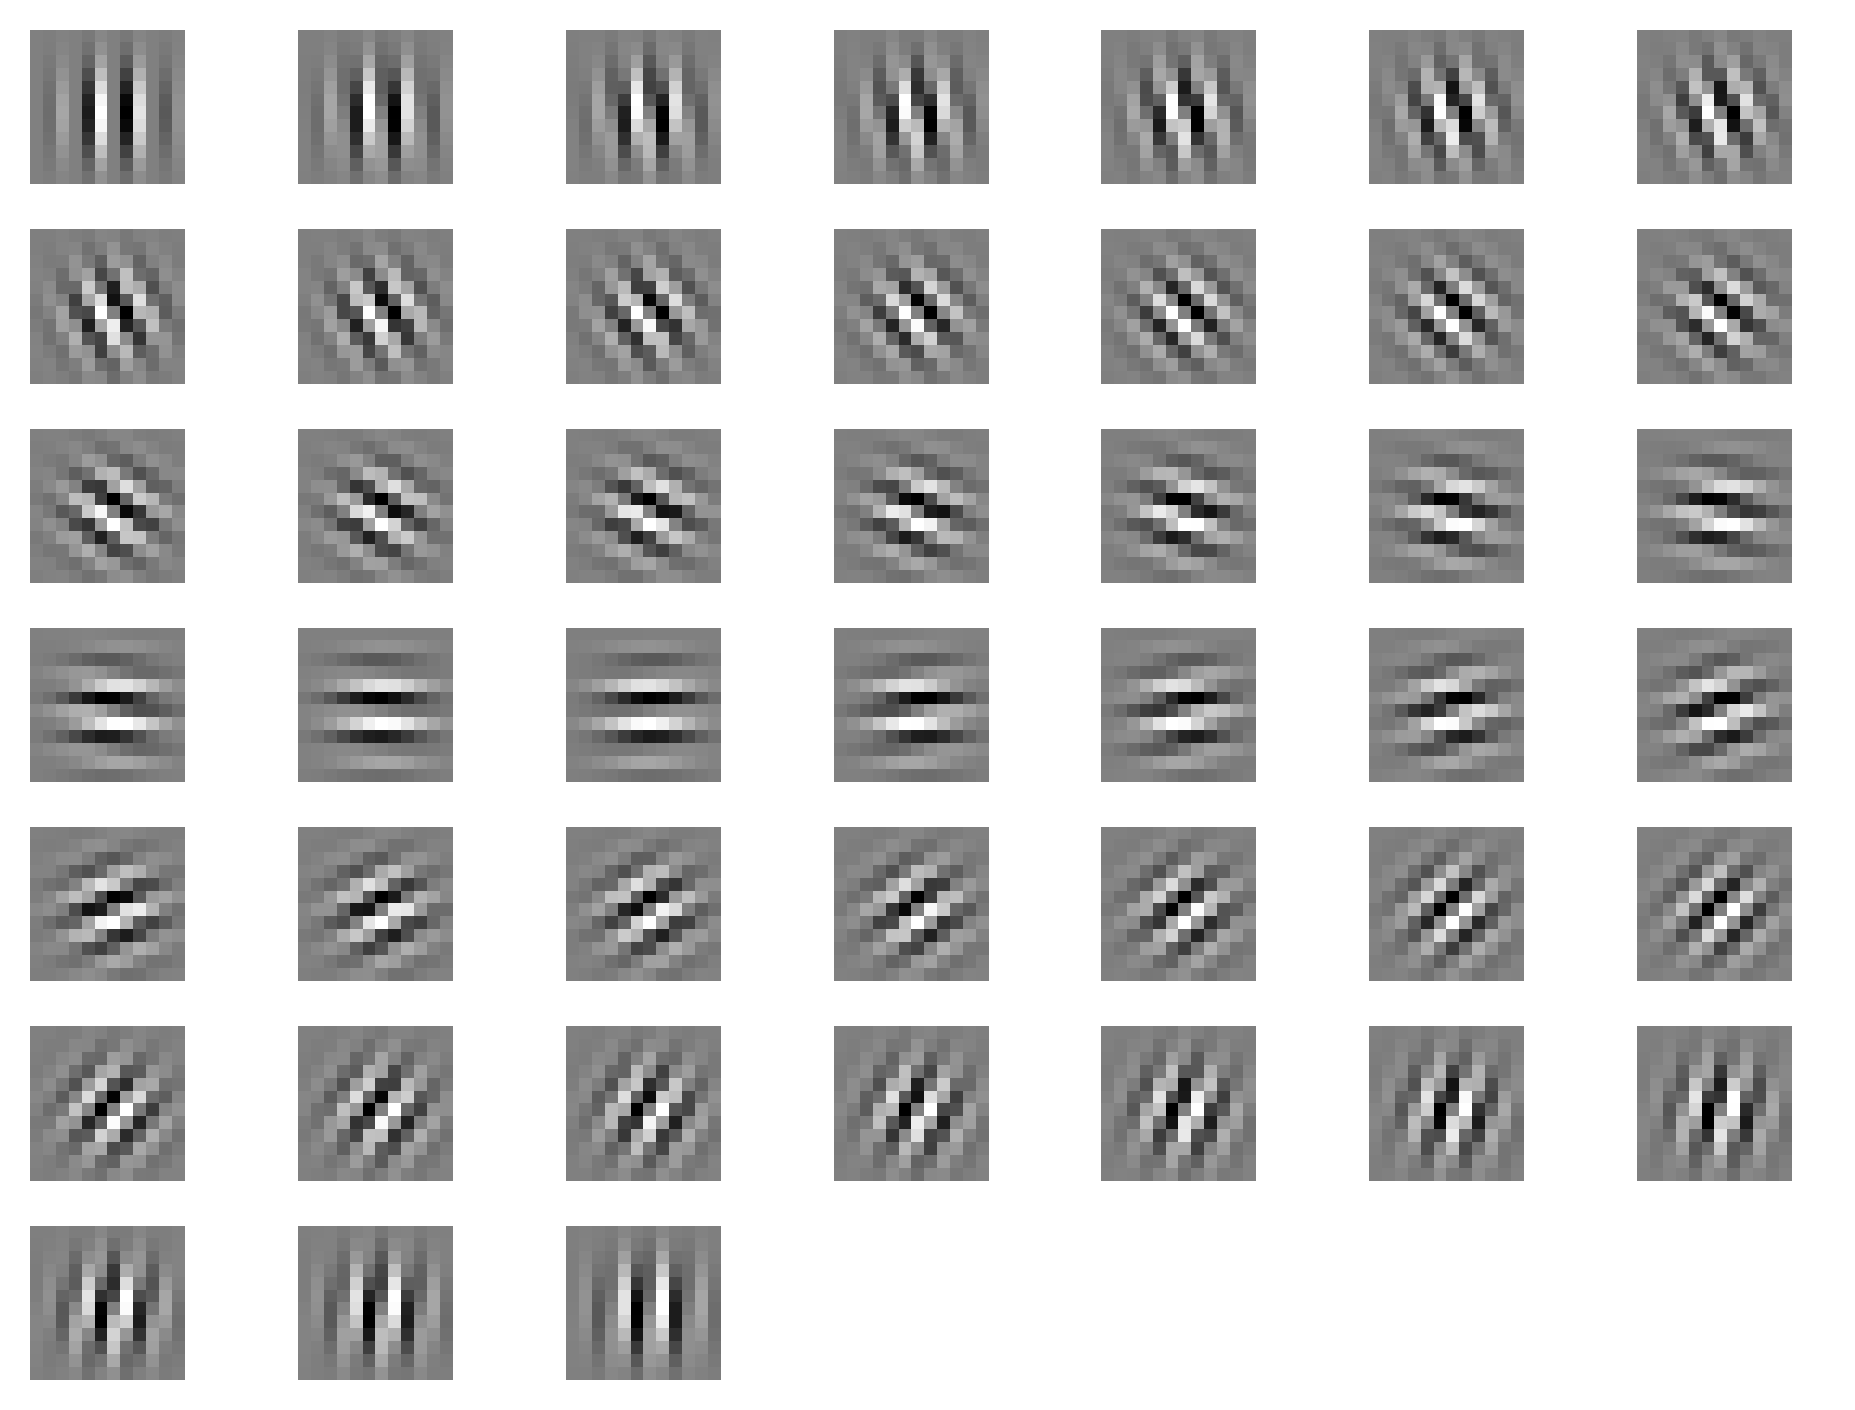

In [17]:
fig, axs = plt.subplots(7, 7, dpi=300, sharey=True)
axs = axs.flatten()
for idx, pf in enumerate(haefner_model.x_pfs):
    axs[idx].imshow(haefner_model.x_pfs[idx].view(12, 12).detach(), cmap="gray")
    axs[idx].axis("off")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

In [37]:
train_scales = []
for responses, images in train_loader:
    dist = likelihood_model.trainable_distribution.distribution(
        cond=responses
    ).base_dist
    train_scales.append(dist.scale.flatten())
train_scales = torch.cat(train_scales, dim=0)

In [38]:
val_scales = []
for responses, images in val_loader:
    dist = likelihood_model.trainable_distribution.distribution(
        cond=responses
    ).base_dist
    val_scales.append(dist.scale.flatten())
val_scales = torch.cat(val_scales, dim=0)

In [41]:
test_scales = []
for responses, images in test_loader:
    dist = likelihood_model.trainable_distribution.distribution(cond=responses).base_dist
    test_scales.append(dist.scale.flatten())
test_scales = torch.cat(test_scales, dim=0)

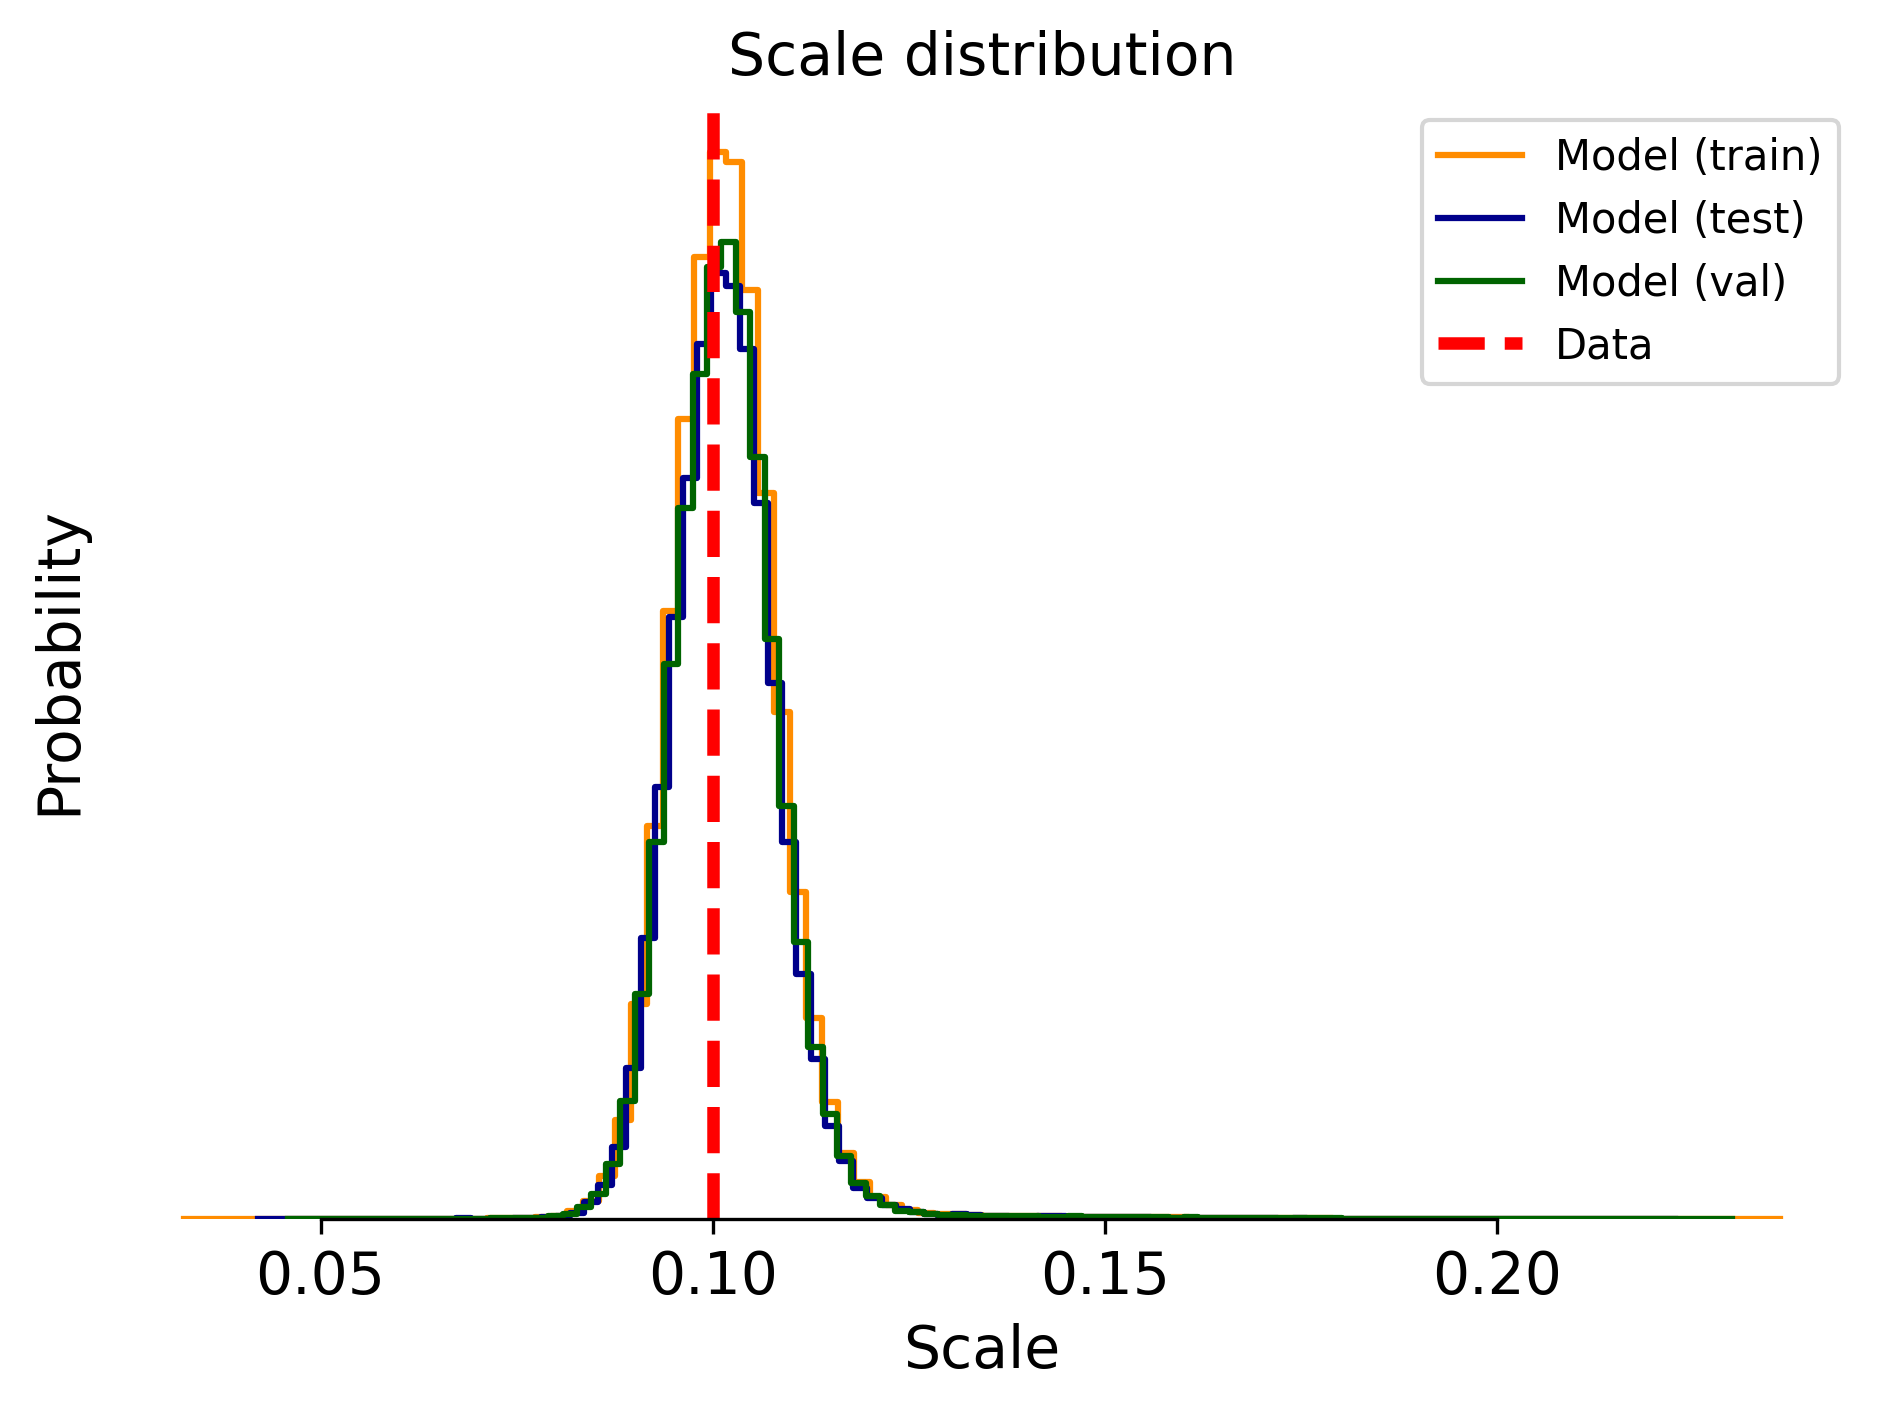

In [51]:
fig, ax = plt.subplots(dpi=300)
sns.histplot(train_scales.detach().numpy(), bins=100, color="darkorange", fill=False, element="step", ax=ax, stat="probability", label="Model (train)")
sns.histplot(test_scales.detach().numpy(), bins=100, color="darkblue", fill=False, element="step", ax=ax, stat="probability", label="Model (test)")
sns.histplot(val_scales.detach().numpy(), bins=100, color="darkgreen", fill=False, element="step", ax=ax, stat="probability", label="Model (val)")
# draw a red line at true scale
plt.axvline(haefner_model.obs_sigma, color="red", linewidth=3, linestyle="--", label="Data")
ax.set_title("Scale distribution", fontsize=14)
ax.set_xlabel("Scale", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.legend()
sns.despine(ax=ax, trim=True)
ax.spines["left"].set_visible(False)
ax.set_yticks([])
plt.tight_layout()